<a href="https://colab.research.google.com/github/ali15121372/ECG/blob/main/Deep_thesis_Ali_Farokhi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Generating a sample ECG signal (for demonstration purposes)
# In practice, you would load your ECG data from a file or other source
fs = 1000  # Sample frequency (Hz)
t = np.linspace(0, 1, fs, endpoint=False)  # Time array
# Creating a sample ECG signal with noise
ecg_signal = 0.5 * np.sin(2 * np.pi * 1.0 * t) + 0.2 * np.sin(2 * np.pi * 50.0 * t)

# Define the bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# Define the filter parameters
lowcut = 0.5  # Lower bound of the bandpass filter (Hz)
highcut = 40.0  # Upper bound of the bandpass filter (Hz)

# Apply the bandpass filter to the ECG signal
filtered_ecg = butter_bandpass_filter(ecg_signal, lowcut, highcut, fs, order=4)

# Plot the original and filtered signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, ecg_signal, label='Original ECG signal')
plt.title('Original ECG Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, filtered_ecg, label='Filtered ECG signal', color='orange')
plt.title('Filtered ECG Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#@title import dara

#!unzip /content/mitbih_test.csv.zip -d /content/test
#!unzip /content/mitbih_train.csv.zip -d /content/train
!unzip /content/drive/MyDrive/ecg-mit-bih/data/mitbih_test.csv.zip -d /content/test
!unzip /content/drive/MyDrive/ecg-mit-bih/data/mitbih_train.csv.zip -d /content/train

Archive:  /content/drive/MyDrive/ecg-mit-bih/data/mitbih_test.csv.zip
  inflating: /content/test/mitbih_test.csv  
Archive:  /content/drive/MyDrive/ecg-mit-bih/data/mitbih_train.csv.zip
  inflating: /content/train/mitbih_train.csv  


In [ ]:
#@title libraries
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import clear_output

import keras
import numpy as np
import pandas as pd
import numpy as np
from sklearn.utils import resample
from keras import optimizers, losses, activations, models
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from keras.layers import Dense, Input, Dropout, Convolution1D, MaxPool1D, GlobalMaxPool1D, GlobalAveragePooling1D, \
    concatenate
from sklearn.metrics import f1_score, accuracy_score



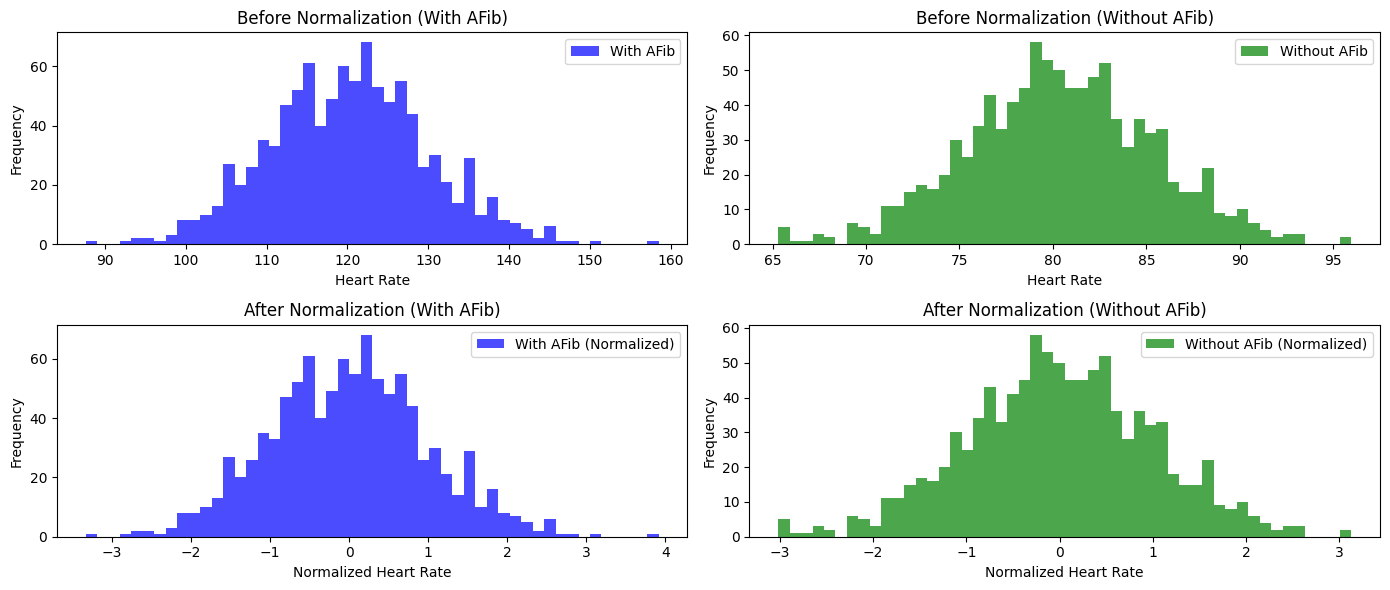

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#  داده‌های مربوط به شخص با فیبریلاسیون دهلیزی
np.random.seed(42)  # برای تکرارپذیری
person_with_afib = np.random.normal(loc=120, scale=10, size=1000)

#  داده‌های مربوط به شخص بدون فیبریلاسیون دهلیزی
person_without_afib = np.random.normal(loc=80, scale=5, size=1000)

# نمایش توزیع اولیه داده‌ها
plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
plt.hist(person_with_afib, bins=50, alpha=0.7, color='blue', label='With AFib')
plt.title('Before Normalization (With AFib)')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(person_without_afib, bins=50, alpha=0.7, color='green', label='Without AFib')
plt.title('Before Normalization (Without AFib)')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.legend()

# نرمال‌سازی داده‌ها با استفاده از Standardization (Z-score Normalization)
mean_with_afib = np.mean(person_with_afib)
std_with_afib = np.std(person_with_afib)
person_with_afib_normalized = (person_with_afib - mean_with_afib) / std_with_afib

mean_without_afib = np.mean(person_without_afib)
std_without_afib = np.std(person_without_afib)
person_without_afib_normalized = (person_without_afib - mean_without_afib) / std_without_afib

# نمایش توزیع داده‌های نرمال‌شده
plt.subplot(2, 2, 3)
plt.hist(person_with_afib_normalized, bins=50, alpha=0.7, color='blue', label='With AFib (Normalized)')
plt.title('After Normalization (With AFib)')
plt.xlabel('Normalized Heart Rate')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 2, 4)
plt.hist(person_without_afib_normalized, bins=50, alpha=0.7, color='green', label='Without AFib (Normalized)')
plt.title('After Normalization (Without AFib)')
plt.xlabel('Normalized Heart Rate')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()


0    72471
4     6431
2     5788
1     2223
3      641
Name: 187, dtype: int64


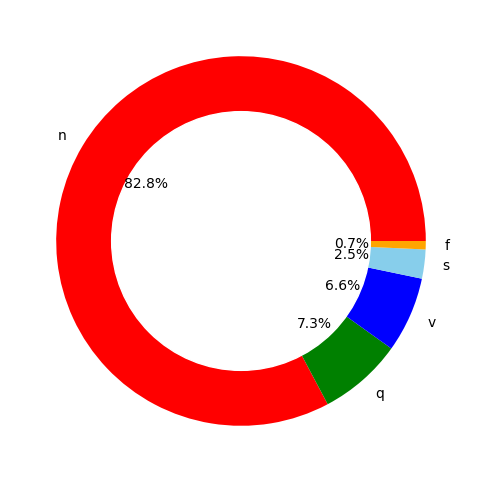

In [ ]:
#@title dataframe

train_df=pd.read_csv('/content/train/mitbih_train.csv',header=None)
test_df=pd.read_csv('/content/test/mitbih_test.csv',header=None)


train_df[187]=train_df[187].astype(int)
equilibre=train_df[187].value_counts()
print(equilibre)

plt.figure(figsize=(12,6))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(equilibre, labels=['n','q','v','s','f'], colors=['red','green','blue','skyblue','orange'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [ ]:
#@title resample
# df_train = pd.read_csv("/content/train/mitbih_train.csv", header=None)
# df_train = df_train.sample(frac=1)


def data_label(file_path):
  csv_data = pd.read_csv(file_path, header=None)
  uniqq=csv_data.iloc[:, -1].astype(int).value_counts()
  Ns=uniqq[0]
  df_0=(csv_data[csv_data[187].astype(int)==0]).sample(n=Ns,random_state=42)
  train_df=[df_0]
  # for making equal datasets
  for i in range(1,5):
    df_1=csv_data[csv_data[187].astype(int)==i]
    df_1_upsample=resample(df_1,replace=True,n_samples=Ns,random_state=i+123)
    train_df.append(df_1_upsample)
  df_train=pd.concat(train_df)
  df_train = df_train.sample(frac=1)
  Y = np.array(df_train[187].values).astype(np.int8)
  X = np.array(df_train[list(range(187))].values)[..., np.newaxis]
  return X,Y




X,Y=data_label('/content/train/mitbih_train.csv')

# X_test,Y_test=data_label('/content/test/mitbih_test.csv')
df_test = pd.read_csv("/content/test/mitbih_test.csv", header=None)
Y_test = np.array(df_test[187].values).astype(np.int8)
X_test = np.array(df_test[list(range(187))].values)[..., np.newaxis]



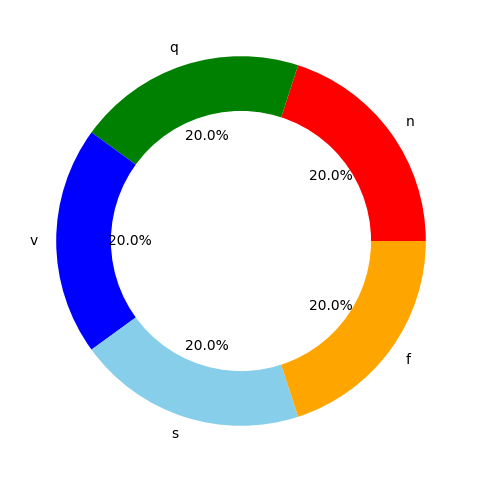

In [ ]:
#@title resample plot
_,count=np.unique(Y,return_counts=True)
plt.figure(figsize=(12,6))
my_circle=plt.Circle( (0,0), 0.7, color='white')
plt.pie(count, labels=['n','q','v','s','f'], colors=['red','green','blue','skyblue','orange'],autopct='%1.1f%%')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

In [ ]:
pip install wfdb


In [ ]:
pip install numpy


In [ ]:
pip install matplotlib


Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


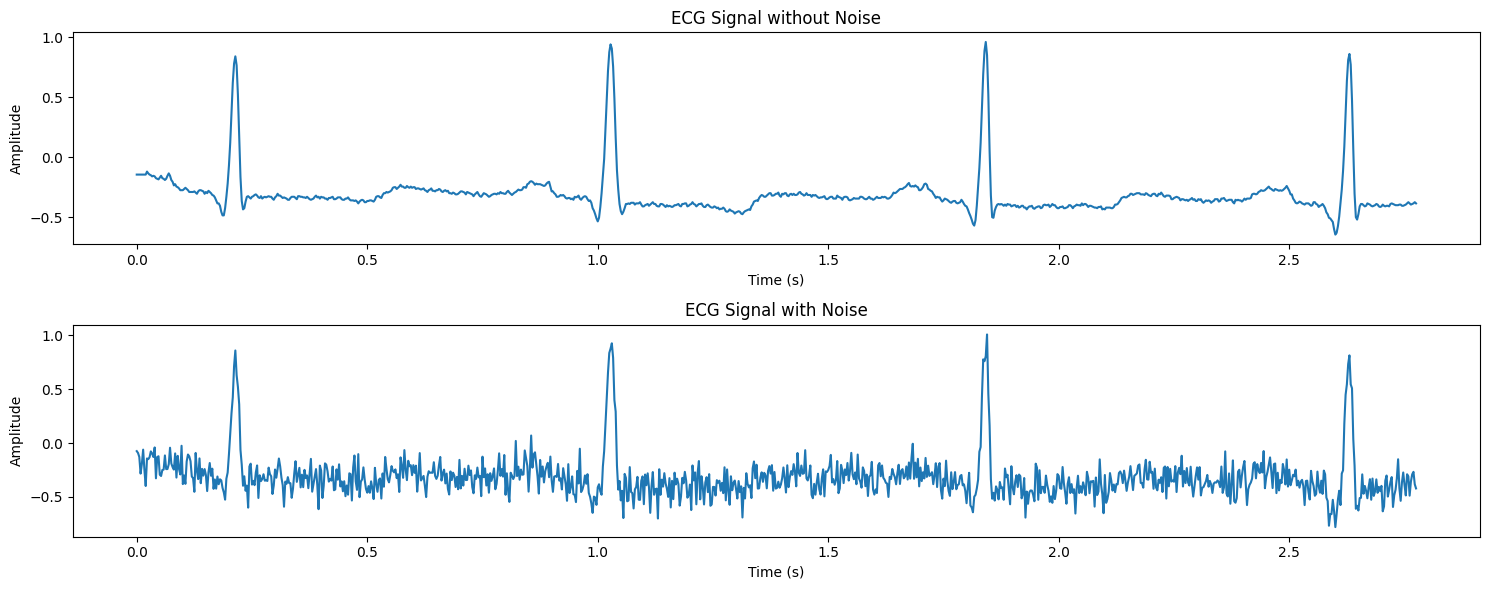

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

#  داده های سیگنال ECG  از PhysioNet
record_name = '100'
wfdb.dl_database('mitdb', './', [record_name])

# بارگذاری داده های سیگنال ECG
record = wfdb.rdrecord(record_name, sampfrom=0, sampto=1000)
ecg_signal = record.p_signal[:,0]

# تنظیمات زمان
fs = record.fs  # نرخ نمونه برداری
t = np.arange(0, len(ecg_signal)) / fs  # بردار زمان


noise = np.random.normal(0, 0.1, len(ecg_signal))
ecg_signal_noisy = ecg_signal + noise

# رسم نمودارها
plt.figure(figsize=(15, 6))

# نمودار سیگنال ECG بدون نویز
plt.subplot(2, 1, 1)
plt.plot(t, ecg_signal)
plt.title('ECG Signal without Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# نمودار سیگنال ECG با نویز
plt.subplot(2, 1, 2)
plt.plot(t, ecg_signal_noisy)
plt.title('ECG Signal with Noise')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


## Extraction

In [ ]:
pip install numpy scipy pandas matplotlib biosppy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import biosppy

# بارگذاری سیگنال ECG از فایل CSV
data = pd.read_csv('ecg_data.csv')
ecg_signal = data['ECG'].values
fs = 360  # نرخ نمونه‌برداری سیگنال

# نمایش سیگنال ECG
plt.plot(ecg_signal[:1000])  # نمایش 1000 نمونه اول
plt.title('ECG Signal')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()


## Find the R wave

In [ ]:
# پیدا کردن قله‌های موج R
peaks, _ = find_peaks(ecg_signal, distance=fs/2.5, height=0.5)

# نمایش قله‌های موج R بر روی سیگنال
plt.plot(ecg_signal[:1000])
plt.plot(peaks[:10], ecg_signal[peaks[:10]], 'rx')  # نمایش 10 قله اول
plt.title('ECG Signal with R Peaks')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()


## Distance **R**

In [ ]:
# محاسبه فاصله R-R
rr_intervals = np.diff(peaks) / fs  # تبدیل به ثانیه

# نمایش توزیع فاصله‌های R-R
plt.hist(rr_intervals, bins=50)
plt.title('R-R Intervals Distribution')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.show()

# محاسبه میانگین و انحراف معیار فاصله‌های R-R
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)

print(f'Mean R-R Interval: {mean_rr:.2f} seconds')
print(f'Standard Deviation of R-R Intervals: {std_rr:.2f} seconds')


## [R wave ***amplitude***]





In [ ]:
# محاسبه دامنه‌های موج R
r_amplitudes = ecg_signal[peaks]

# نمایش توزیع دامنه‌های موج R
plt.hist(r_amplitudes, bins=50)
plt.title('R-wave Amplitudes Distribution')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.show()

# محاسبه میانگین و انحراف معیار دامنه‌های موج R
mean_r_amp = np.mean(r_amplitudes)
std_r_amp = np.std(r_amplitudes)

print(f'Mean R-wave Amplitude: {mean_r_amp:.2f}')
print(f'Standard Deviation of R-wave Amplitudes: {std_r_amp:.2f}')


## Feature **extraction**

In [ ]:
import biosppy.signals.ecg as ecg

# تحلیل سیگنال ECG
out = ecg.ecg(signal=ecg_signal, sampling_rate=fs, show=False)

# استخراج ویژگی‌های زمانی از سیگنال
heart_rate = out['heart_rate']  # نرخ ضربان قلب
templates = out['templates']    # قالب‌های ضربان قلب

# نمایش قالب‌های ضربان قلب
plt.plot(templates.T)
plt.title('ECG Templates')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

# محاسبه میانگین و انحراف معیار نرخ ضربان قلب
mean_hr = np.mean(heart_rate)
std_hr = np.std(heart_rate)

print(f'Mean Heart Rate: {mean_hr:.2f} BPM')
print(f'Standard Deviation of Heart Rate: {std_hr:.2f} BPM')


## **FFT**

In [ ]:
from scipy.fftpack import fft

# اعمال FFT بر روی سیگنال ECG
N = len(ecg_signal)  # تعداد نمونه‌ها
T = 1.0 / fs  # بازه زمانی نمونه‌برداری
yf = fft(ecg_signal)
xf = np.fft.fftfreq(N, T)[:N//2]

#  تبدیل فوریه سیگنال ECG
plt.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.title('FFT of ECG Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()


## spectral power

In [ ]:
# محاسبه توان طیفی
power_spectral_density = (2.0/N * np.abs(yf[:N//2]))**2

# محاسبه توان طیفی
plt.plot(xf, power_spectral_density)
plt.title('Power Spectral Density of ECG Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.show()


In [ ]:
# محاسبه میانگین و انحراف معیار توان طیفی
mean_psd = np.mean(power_spectral_density)
std_psd = np.std(power_spectral_density)

# محاسبه فرکانس غالب (فرکانسی که بیشترین توان را دارد)
dominant_freq = xf[np.argmax(power_spectral_density)]

print(f'Mean Power Spectral Density: {mean_psd:.2e}')
print(f'Standard Deviation of Power Spectral Density: {std_psd:.2e}')
print(f'Dominant Frequency: {dominant_freq:.2f} Hz')


In [ ]:
# محاسبه ویژگی‌های آماری اصلی
mean_val = np.mean(ecg_signal)
std_val = np.std(ecg_signal)
var_val = np.var(ecg_signal)
min_val = np.min(ecg_signal)
max_val = np.max(ecg_signal)
range_val = max_val - min_val
median_val = np.median(ecg_signal)

print(f'Mean: {mean_val:.2f}')
print(f'Standard Deviation: {std_val:.2f}')
print(f'Variance: {var_val:.2f}')
print(f'Minimum: {min_val:.2f}')
print(f'Maximum: {max_val:.2f}')
print(f'Range: {range_val:.2f}')
print(f'Median: {median_val:.2f}')


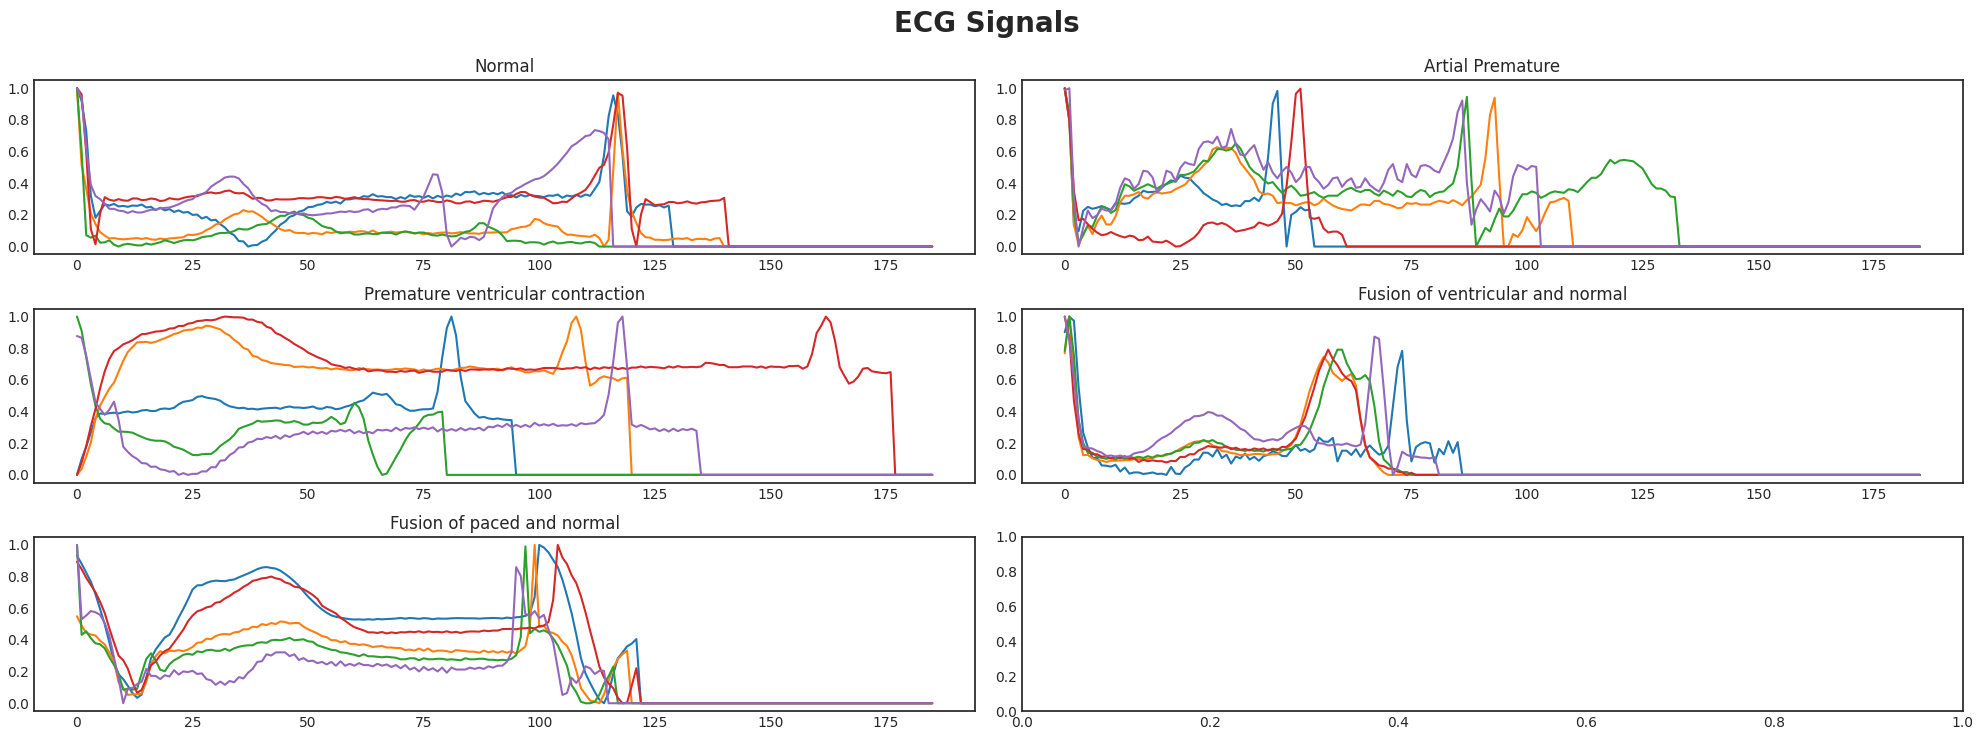

In [ ]:
#@title plot signal
id_to_label = {
    0: "Normal",
    1: "Artial Premature",
    2: "Premature ventricular contraction",
    3: "Fusion of ventricular and normal",
    4: "Fusion of paced and normal"
}
N = 5
samples = [train_df.loc[train_df[187].astype(int) == cls].sample(N) for cls in range(N)]
titles = [id_to_label[cls] for cls in range(N)]

with plt.style.context("seaborn-white"):
    fig, axs = plt.subplots(3, 2, figsize=(20, 7))
    for i in range(5):
        ax = axs.flat[i]
        ax.plot(samples[i].values[:,:-2].transpose())
        ax.set_title(titles[i])
        #plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.suptitle("ECG Signals", fontsize=20, y=1.05, weight="bold")
    plt.savefig(f"signals_per_class.svg",
                    format="svg",bbox_inches='tight', pad_inches=0.2)

    plt.savefig(f"signals_per_class.png",
                    format="png",bbox_inches='tight', pad_inches=0.2)

In [ ]:
#@title callback plot
class TrainingPlot(keras.callbacks.Callback):

    # This function is called when the training begins
    def on_train_begin(self, logs={}):
        # Initialize the lists for holding the logs, losses and accuracies
        self.losses = []
        self.acc = []
        self.val_losses = []
        self.val_acc = []
        self.logs = []

    # This function is called at the end of each epoch
    def on_epoch_end(self, epoch, logs={}):

        # Append the logs, losses and accuracies to the lists
        self.logs.append(logs)
        self.losses.append(logs.get('loss'))
        self.acc.append(logs.get('acc'))
        self.val_losses.append(logs.get('val_loss'))
        self.val_acc.append(logs.get('val_acc'))

        # Before plotting ensure at least 2 epochs have passed
        if len(self.losses) > 1:

            # Clear the previous plot
            clear_output(wait=True)
            N = np.arange(0, len(self.losses))

            # You can chose the style of your preference
            # print(plt.style.available) to see the available options
            plt.style.use("seaborn")

            # Plot train loss, train acc, val loss and val acc against epochs passed
            plt.figure()
            plt.subplot(1, 2, 1)
            plt.plot(N, self.losses, label = "train_loss")
            plt.plot(N, self.val_losses, label = "val_loss")
            plt.title("Training Loss [Epoch {}]".format(epoch))
            plt.xlabel("Epoch #")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()
            plt.subplot(1, 2, 2)
            plt.plot(N, self.acc, label = "train_acc")
            plt.plot(N, self.val_acc, label = "val_acc")
            plt.title("Training Accuracy [Epoch {}]".format(epoch))
            plt.xlabel("Epoch #")
            plt.ylabel("Accuracy")
            plt.legend()
            plt.show()
            plt.tight_layout()


plot_losses = TrainingPlot()

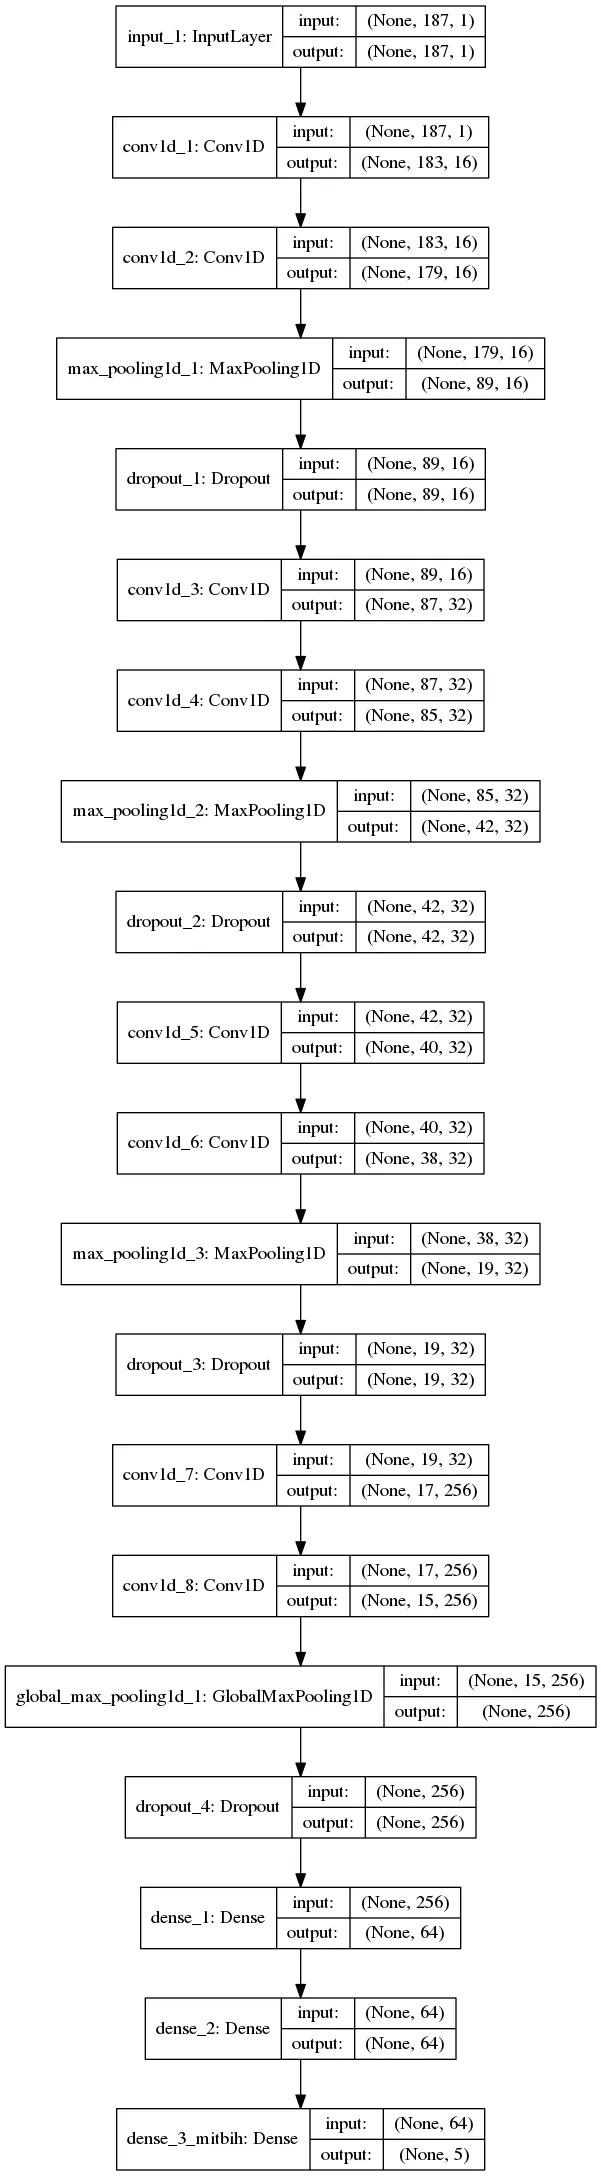

In [ ]:
#@title Model
def get_model():
    nclass = 5
    inp = Input(shape=(187, 1))
    img_1 = Convolution1D(16, kernel_size=5, activation=activations.relu, padding="valid")(inp)
    img_1 = Convolution1D(16, kernel_size=5, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(256, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(256, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = GlobalMaxPool1D()(img_1)
    img_1 = Dropout(rate=0.2)(img_1)

    dense_1 = Dense(64, activation=activations.relu, name="dense_1")(img_1)
    dense_1 = Dense(64, activation=activations.relu, name="dense_2")(dense_1)
    dense_1 = Dense(nclass, activation=activations.softmax, name="dense_3_mitbih")(dense_1)

    model = models.Model(inputs=inp, outputs=dense_1)
    opt = optimizers.Adam(0.001)

    model.compile(optimizer=opt, loss=losses.sparse_categorical_crossentropy, metrics=['acc'])
    model.summary()
    return model

model = get_model()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 183, 16)           96        
                                                                 
 conv1d_1 (Conv1D)           (None, 179, 16)           1296      
                                                                 
 max_pooling1d (MaxPooling1  (None, 89, 16)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 89, 16)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 87, 32)            1568      
                                                             

In [ ]:
#@title Learning Phase


file_path = "baseline_cnn_mitbih.h5"
checkpoint = ModelCheckpoint(file_path, monitor='val_loss', verbose=1, save_best_only=True, mode='max')
early = EarlyStopping(monitor="val_acc", mode="max", patience=5, verbose=1)
redonplat = ReduceLROnPlateau(monitor="val_acc", mode="max", patience=3, verbose=2)
callbacks_list = [checkpoint, early, redonplat,plot_losses]  # early

history=model.fit(X, Y, epochs=100, verbose=2, callbacks=callbacks_list, validation_split=0.2)
!cp baseline_cnn_mitbih.h5 /content/drive/MyDrive/baseline_cnn_mitbih.h5

In [ ]:
#@title test
# file_path = "/content/drive/MyDrive/baseline_cnn_mitbih.h5"
model.load_weights(file_path)

pred_test = model.predict(X_test)
pred_test = np.argmax(pred_test, axis=-1)

f1 = f1_score(Y_test, pred_test, average="macro")

print("Test f1 score : %s "% f1)

acc = accuracy_score(Y_test, pred_test)

print("Test accuracy score : %s "% acc)

In [ ]:
#@title confusion matrix
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(Y_test, pred_test)
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Compute confusion matrix
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(10, 10))
plot_confusion_matrix(cnf_matrix, classes=['N', 'S', 'V', 'F', 'Q'],normalize=True,
                      title='Confusion matrix, with normalization')
plt.show()

## Dataset and DataLoader

In [ ]:
class ECGDataset(Dataset):

    def __init__(self, df):
        self.df = df
        self.data_columns = self.df.columns[:-2].tolist()

    def __getitem__(self, idx):
        signal = self.df.loc[idx, self.data_columns].astype('float32')
        signal = torch.FloatTensor([signal.values])
        target = torch.LongTensor(np.array(self.df.loc[idx, 'class']))
        return signal, target

    def __len__(self):
        return len(self.df)

In [ ]:
def get_dataloader(phase: str, batch_size: int = 96) -> DataLoader:
    '''
    Dataset and DataLoader.
    Parameters:
        pahse: training or validation phase.
        batch_size: data per iteration.
    Returns:
        data generator
    '''
    df = pd.read_csv(config.train_csv_path)
    train_df, val_df = train_test_split(
        df, test_size=0.15, random_state=config.seed, stratify=df['label']
    )
    train_df, val_df = train_df.reset_index(drop=True), val_df.reset_index(drop=True)
    df = train_df if phase == 'train' else val_df
    dataset = ECGDataset(df)
    dataloader = DataLoader(dataset=dataset, batch_size=batch_size, num_workers=4)
    return dataloader

![](https://64.media.tumblr.com/e42e20eb2ec1aea3962c6ace63adf499/70877119c7741403-44/s540x810/c8f722eb2ab3d92c98070554db4815ca8c01510b.png)

## Experiments and Results

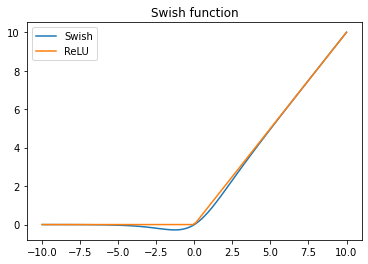

In [ ]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

x = torch.linspace(-10.0, 10.0, 100)
swish = Swish()
swish_out = swish(x)
relu_out = torch.relu(x)

plt.title('Swish function')
plt.plot(x.numpy(), swish_out.numpy(), label='Swish')
plt.plot(x.numpy(), relu_out.numpy(), label='ReLU')
plt.legend();
plt.show()

In [ ]:
cnn_model = CNN(num_classes=5, hid_size=128).to(config.device)
cnn_model.load_state_dict(
    torch.load(config.cnn_state_path,
               map_location=config.device)
);
cnn_model.eval();
logs = pd.read_csv(config.cnn_logs)

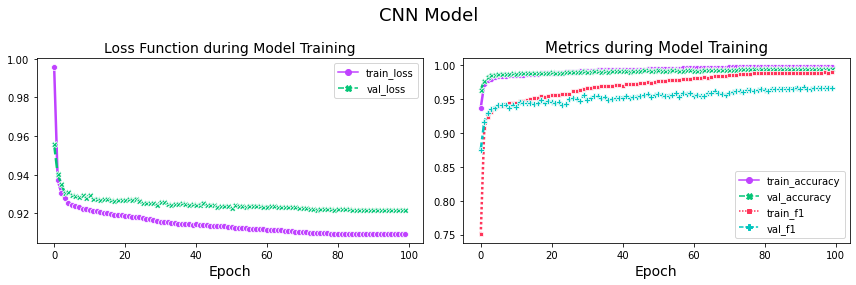

In [ ]:
colors = ['#C042FF', '#03C576FF', '#FF355A', '#03C5BF', '#96C503', '#C5035B']
palettes = [sns.color_palette(colors, 2),
            sns.color_palette(colors, 4),
            sns.color_palette(colors[:2]+colors[-2:] + colors[2:-2], 6)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=logs.iloc[:, :2], palette=palettes[0], markers=True, ax=ax[0], linewidth=2.5,)
ax[0].set_title("Loss Function during Model Training", fontsize=14)
ax[0].set_xlabel("Epoch", fontsize=14)

sns.lineplot(data=logs.iloc[:, 2:6], palette=palettes[1], markers=True, ax=ax[1], linewidth=2.5, legend="full")
ax[1].set_title("Metrics during Model Training", fontsize=15)
ax[1].set_xlabel("Epoch", fontsize=14)

plt.suptitle('CNN Model', fontsize=18)

plt.tight_layout()
fig.savefig("cnn.png", format="png",  pad_inches=0.2, transparent=False, bbox_inches='tight')
fig.savefig("cnn.svg", format="svg",  pad_inches=0.2, transparent=False, bbox_inches='tight')

In [ ]:
lstm_model = RNNModel(1, 64, 'lstm', True).to(config.device)
lstm_model.load_state_dict(
    torch.load(config.lstm_state_path,
               map_location=config.device)
);
lstm_model.eval();
logs = pd.read_csv(config.lstm_logs)

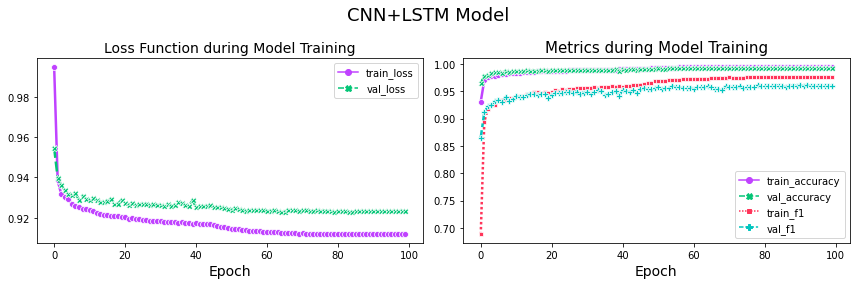

In [ ]:
colors = ['#C042FF', '#03C576FF', '#FF355A', '#03C5BF', '#96C503', '#C5035B']
palettes = [sns.color_palette(colors, 2),
            sns.color_palette(colors, 4),
            sns.color_palette(colors[:2]+colors[-2:] + colors[2:-2], 6)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=logs.iloc[:, :2], palette=palettes[0], markers=True, ax=ax[0], linewidth=2.5,)
ax[0].set_title("Loss Function during Model Training", fontsize=14)
ax[0].set_xlabel("Epoch", fontsize=14)

sns.lineplot(data=logs.iloc[:, 2:6], palette=palettes[1], markers=True, ax=ax[1], linewidth=2.5, legend="full")
ax[1].set_title("Metrics during Model Training", fontsize=15)
ax[1].set_xlabel("Epoch", fontsize=14)

plt.suptitle('CNN+LSTM Model', fontsize=18)

plt.tight_layout()
fig.savefig("lstm.png", format="png",  pad_inches=0.2, transparent=False, bbox_inches='tight')
fig.savefig("lstm.svg", format="svg",  pad_inches=0.2, transparent=False, bbox_inches='tight')